#**Synapse Week One**

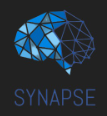

Last week, we focused on building the foundations needed to get started with Machine Learning. We explored Python and learned how to work with and understand data through Exploratory Data Analysis (EDA).

Now, it is time to take the next step and use that knowledge to build our first Machine Learning model. In this task, we will explore Regression, a type of supervised learning where the goal is to predict a continuous numerical value.

We will begin by exploring an insurance dataset and using EDA to understand the relationships between its different attributes and the insurance charges. Once we understand our data, we will prepare it for Machine Learning and build a Linear Regression model to predict the incurred charges.

But we won't stop at simply using a library. We will also take a look under the hood and implement Linear Regression from scratch, giving us a better understanding of what happens when a model is trained.

Resources and comments are provided throughout the notebook. Go through them carefully, understand the concepts, and then get coding.

Let's get started.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

https://www.geeksforgeeks.org/ml-classification-vs-regression/
(Short and Sweet)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [58]:
!pip install shap -q

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
pd
pd.DataFrame()

""


In [62]:
arr = np.array([1, 2, 3, 4, 5])
arr * 2

array([ 2,  4,  6,  8, 10])

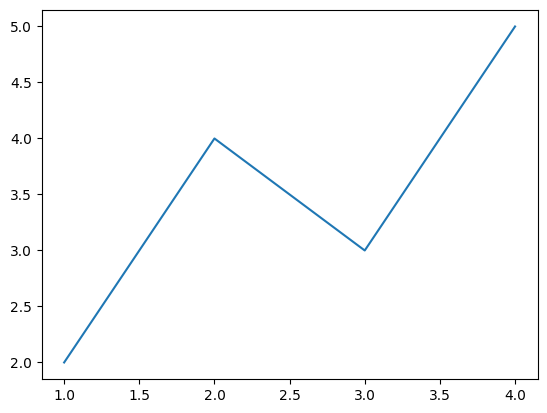

In [63]:
plt.plot([1, 2, 3, 4], [2, 4, 3, 5])
plt.show()

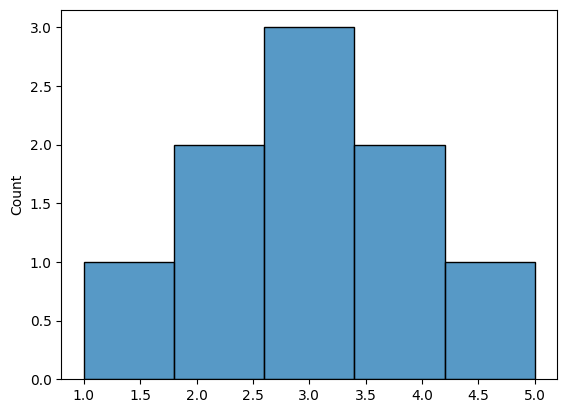

In [64]:
sb.histplot([1, 2, 2, 3, 3, 3, 4, 4, 5])
plt.show()

# Regression

For regression we will use insurance dataset, which contains medical costs incurred
https://drive.google.com/file/d/1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ/view?usp=sharing

## Basic EDA

In [65]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'insurance' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/insurance.csv


In [66]:
f=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')

### Use the very first steps involved in EDA -> info, head and describe

In [67]:
f.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [68]:
f.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [69]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [70]:
f.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Now, plot a histogram to understand insurance charges *distribution*

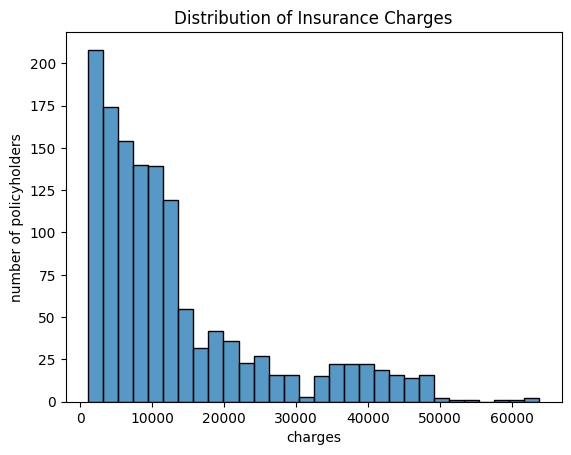

In [71]:
import seaborn as sb
sb.histplot(f['charges'])

plt.title('Distribution of Insurance Charges')
plt.xlabel('charges')
plt.ylabel('number of policyholders')

plt.show()

### Plot a scatter plot between age and insurance charges

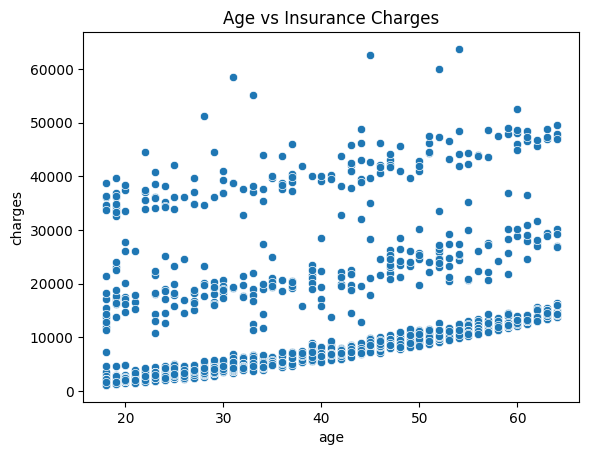

In [72]:
sb.scatterplot(x='age', y='charges', data=f)

plt.title('Age vs Insurance Charges')
plt.xlabel('age')
plt.ylabel('charges')

plt.show()

### Similarly, plot scatterplots for no. of children and charges, and also for bmi and charges


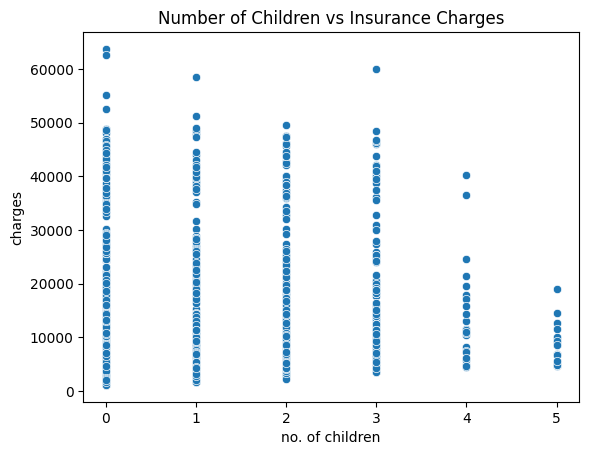

In [73]:
sb.scatterplot(x= "children" ,y="charges", data = f)

plt.title('Number of Children vs Insurance Charges')
plt.xlabel('no. of children')
plt.ylabel('charges')

plt.show()

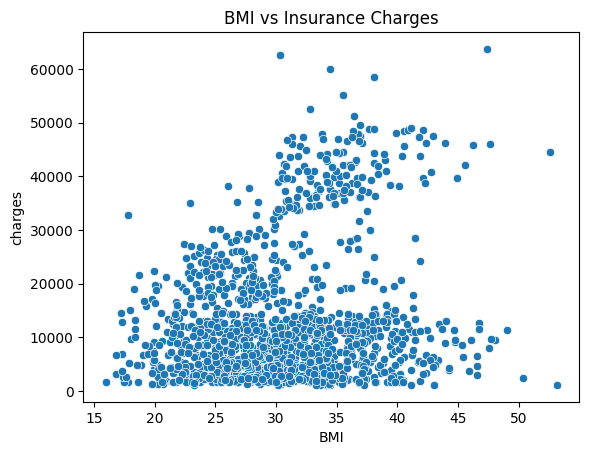

In [74]:
sb.scatterplot(x= "bmi" ,y="charges", data = f)

plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('charges')

plt.show()

### Now, use boxplots to find correlation between Sex and Charges, between Smoker and charges, and also between region and charges

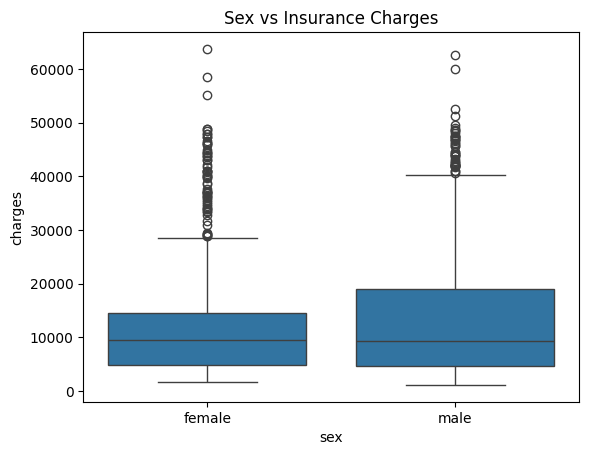

In [75]:
sb.boxplot(data=f, x='sex', y='charges')

plt.title('Sex vs Insurance Charges')
plt.xlabel('sex')
plt.ylabel('charges')

plt.show()

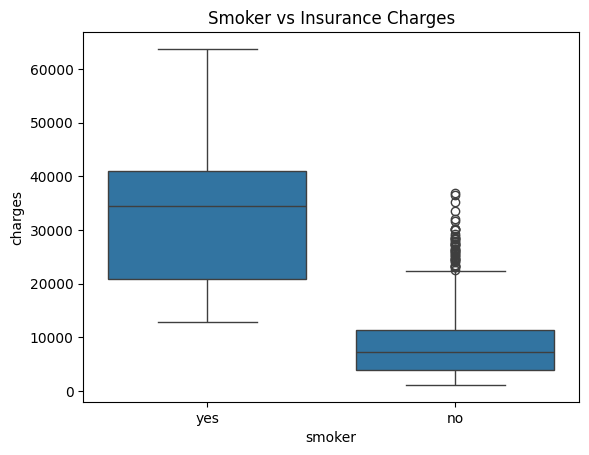

In [76]:
sb.boxplot(data=f, x='smoker', y='charges')

plt.title('Smoker vs Insurance Charges')
plt.xlabel('smoker')
plt.ylabel('charges')

plt.show()

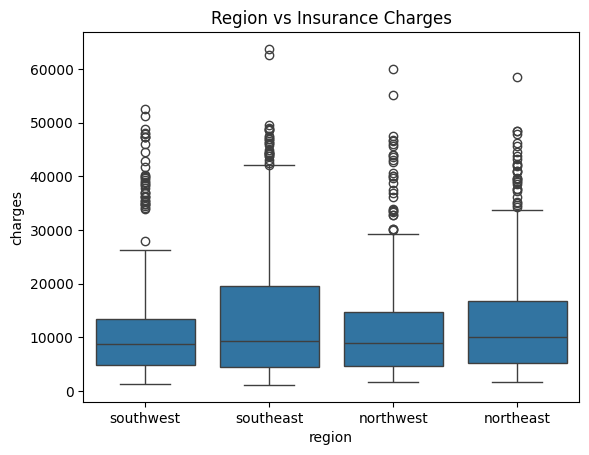

In [77]:
sb.boxplot(data=f, x='region', y='charges')

plt.title('Region vs Insurance Charges')
plt.xlabel('region')
plt.ylabel('charges')

plt.show()

##### Now, make a heatmap to understand correlation between all attributes

In [78]:
f.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


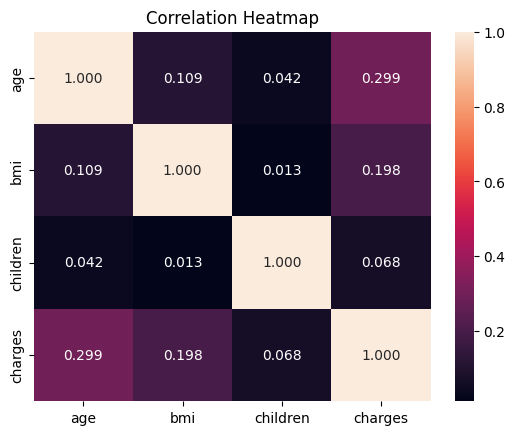

In [79]:
sb.heatmap(
    f[['age', 'bmi', 'children', 'charges']].corr(), annot=True, fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()

## Question: What do you infer from the above analysis🤔

### Answer here:
##### From histogram- Since the data was right skewed, most people have lower insurance charges and just a few have high insurance charges.
##### From scatterplots- Age and charges have a positive relationship, as in charges increase as age increases, but its not always constant. In the case of no. of childern and charges, its difficult to derive a proper relation, and thus it has a weak relationship. For BMI and charges, higher BMI usually has higher charges.
##### From boxplots- Males and females have similar charges. Smokers have much higher charges. Region doesn't affect charges alot either as it looks similar for all.



### Now let's prep our data to perform Regression to predict the Incurred Charges

### Again do df.info() see how the datatype is

In [80]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### As you can see, sex, region and smoker attributes are of the object data type.
### So, convert them into numerical labels, using Label Encoder

In [81]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
f['sex'] = le.fit_transform(f['sex'])
f['smoker'] = le.fit_transform(f['smoker'])
f['region'] = le.fit_transform(f['region'])

In [82]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


Do df.head() to see how your dataframe looks like after LabelEncoding

In [83]:
f.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Question: What does label encoder do? 🤔

### Answer here:
##### Label encoder converts different categories and gives each a number label that is then used in place of the category name.

### Now that you already know about standardization and normalization (I hope🙃), implement normalization here here:


#### Import MinMaxScaler from sklearn and normalize the coloums - ['age', 'bmi', 'children', 'charges']



### Answer:

In [84]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

f[['age','bmi', 'children', 'charges']] = scaler.fit_transform(f[['age', 'bmi', 'children', 'charges']])

In [85]:
f.dtypes

,0
age,float64
sex,int64
bmi,float64
children,float64
smoker,int64
region,int64
charges,float64


In [86]:
f.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,0,0.321227,0.0,1,3,0.251611
1,0.000000,1,0.479150,0.2,0,2,0.009636
2,0.217391,1,0.458434,0.6,0,2,0.053115
3,0.326087,1,0.181464,0.0,0,1,0.333010
4,0.304348,1,0.347592,0.0,0,1,0.043816


## Question: Why standardization is not needed here? 🤔



### Answer:
##### in normalization basically - min becomes 0 and max becomes 1 so the values are generally between 0 and 1.
##### in standardization - mean becomes zero and standard deviation becomes 1.

As we are going to predict Insurance Charges, let us make two sections: one containing only the 'charges', and the other containing all values except for 'charges'

In [87]:
X = f.drop('charges', axis=1) #axis =1 -> column, axis =0 -> row
y = f['charges']

In [88]:
X.head()

,age,sex,bmi,children,smoker,region
0,0.021739,0,0.321227,0.0,1,3
1,0.000000,1,0.479150,0.2,0,2
2,0.217391,1,0.458434,0.6,0,2
3,0.326087,1,0.181464,0.0,0,1
4,0.304348,1,0.347592,0.0,0,1


In [89]:
y.head()

,charges
0,0.251611
1,0.009636
2,0.053115
3,0.333010
4,0.043816


### Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

### Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [90]:
from sklearn.model_selection import train_test_split

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(936, 6)
(402, 6)
(936,)
(402,)


### The data is now split into 2 datasets of size 70% and 30% of original dataset. Surprised? 😮

### We have preprocessed our DataFrame now we'll perform Regression on this Data

### First lets understand Linear Regression, watch this video carefully it will be helpfull later on :)

https://www.youtube.com/watch?v=7ArmBVF2dCs

### A quick article
https://www.analyticsvidhya.com/blog/2021/08/understanding-linear-regression-with-mathematical-insights/

In [92]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

regressor.fit(X_train, y_train)

LinearRegression()

#### The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

#### Use regressor.predict() on X_test and store it in a variable called "y_pred". Print type and size of the y_pred.

#### Size should be 402 if everything is correct. Yeh line confirm karna hai

In [93]:
y_pred = regressor.predict(X_test)
print(y_pred[:10])

print(type(y_pred))

[0.11458173 0.07624277 0.22475371 0.16864488 0.04186476 0.13720372
 0.14116907 0.40032031 0.11002979 0.48133259]
<class 'numpy.ndarray'>


In [94]:
print(y_pred.shape)

(402,)


In [95]:
print("Coefficients:", regressor.coef_)
print("Intercept:", regressor.intercept_)

Coefficients: [ 0.19609363 -0.00441338  0.19726963  0.04923062  0.3872677  -0.00459097]
Intercept: -0.053880005875817816


In [96]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

MSE: 0.009319555619148188
RMSE: 0.09653784552779385


In [97]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7183245518407815


### Visualize the predictions, plot a scatter plot of y_test vs y_pred and also plot the best fit line

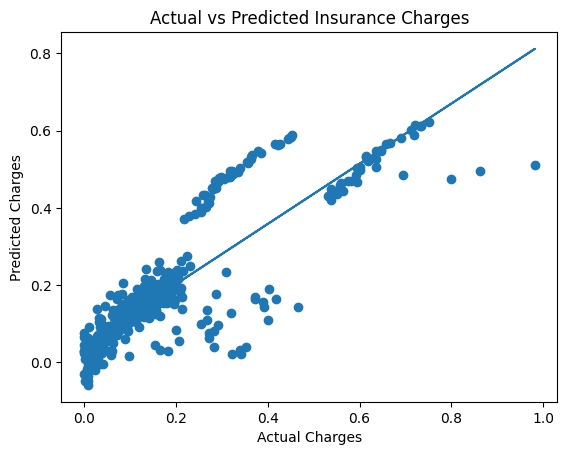

In [98]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')

plt.show()

# Now let's start the fun part 😃

### Have you ever wondered what happens when you call **'regressor.fit(X_train, y_train)'** ?

### To understand what's hapenning in .fit method we will be implementing Linear Regression from scratch.

In [99]:
class LinearRegression():

#to initialise learning rate and iterations-
  def __init__(self, learning_rate, iterations):
    self.learning_rate = learning_rate
    self.iterations = iterations

  def fit(self, X, y):
    self.m, self.n = X.shape #to check no. of rows(no. or training sets) and columns(features)
    self.W = np.zeros(self.n) #create a w(coeff of X) for per feature, and init to 0
    self.b = 0
    self.X = X
    self.y = y

    for i in range(self.iterations):
      self.update_weights()

    return self

  def update_weights(self):
    Y_pred = self.predict(self.X) #make predictions for y to calculate error and then update accordingly

    dW = - (2 * (self.X.T).dot(self.y - Y_pred)) / self.m
    db = - 2 * np.sum(self.y - Y_pred) / self.m
    self.W = self.W - self.learning_rate * dW #updates w and b
    self.b = self.b - self.learning_rate * db

    return self

  def predict(self, X):
    return X.dot(self.W) + self.b #returns y predicted



In [100]:
regressor = LinearRegression(learning_rate=0.01, iterations=1000)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)


## Question: What is this function actually doing? 🤔
#### Answer Here
##### the function fit first takes w and b and then updates it according to gradient descent such that error(mse) is minimised. after multiple iterations we get an estimated value of w and b that we use to make the fitted line.

### Now predict the output for the test data

In [101]:
y_pred = regressor.predict(X_test)
print(y_pred)

7       0.126893
999     0.101842
1209    0.198112
491     0.182302
625     0.074291
          ...   
854     0.535599
554     0.103073
1278    0.494621
374     0.046701
6       0.154516
Length: 402, dtype: float64


### Calculate the mean squared error


In [102]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.009410848240566873


### Plot a similar scatter plot as above


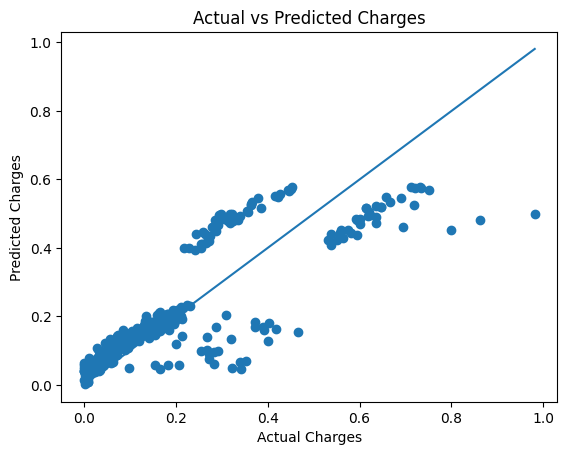

In [103]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
        )

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

How to Approach the Research Tasks :)

Guys, one important thing about how you should approach these tasks.

The links and videos provided are meant to be read/watched. Go through them, understand the concepts, and then write what you understood in your own words. You can also find your own resources — don't restrict yourself to the links we provide.

And please, don’t just GPT your way through the tasks. These are your foundational basics, so actually understand what you're doing. Try reading documentation, Stack Overflow discussions, technical articles, etc. These will become your best guides when you're learning ML independently.

The Research Task is compulsory and one of the most important parts of your learning, irrespective of what you do. Research is an engineer's way of learning — it's how you learn ML for what it actually is, rather than just learning how to write the code.

For the Research Task, research properly, understand what you find, and explain it in your own words. No implementation is required unless mentioned.

The best Research Task submission after every task will be featured on Synapse's LinkedIn with a tag, giving you an opportunity to connect with our alumni and seniors and grow your network.

So don't treat the Research Task as just another question to finish. Actually explore, understand, and learn from it :)

## Research Task: Underfitting & Overfitting

We’ve now built our first Linear Regression model. Before moving ahead, let’s understand an important problem that can affect any ML model: **Underfitting and Overfitting**.

### Resources

Read/watch the following:

* [SuperAnnotate — Overfitting & Underfitting](https://www.superannotate.com/blog/overfitting-and-underfitting-in-machine-learning) — simple theory and intuition
* [GreyAtom — Underfitting & Overfitting](https://medium.com/greyatom/what-is-underfitting-and-overfitting-in-machine-learning-and-how-to-deal-with-it-6803a989c76) — includes mathematical intuition
* [2-minute video](https://youtu.be/pptU3bpJojo?si=1uZ4yO_OQGkvEym-) — quick visual explanation

You can also find your **own resources** if you want to understand something better.

### Your Task

After going through the resources, write **what you understood in your own words**.

Make sure you can explain:

* What is underfitting?
* What is overfitting?
* What are **bias and variance**, and how are they related to underfitting and overfitting?
* How can you identify whether a model is underfitting or overfitting?
* Mention at least **one way to deal with each**.

You don't need to copy definitions from the resources. The goal is to see whether **you actually understand the concept and can explain it yourself**.

**No implementation is required.** Focus on understanding the concepts and explaining them clearly.

*Good Luck People :)*


#### Concepts I understood-

##### Underfitting- occurs whem the model is not able to collect enough assumptions to be able to predict the data properly. Patterns arent enough, or the main relation to predict data is not idenetified. Thus the model doesnt perform well, as it is too simple. It has high bias and low variance.

##### Overfitting- occurs when the training data is looked extremely closely including the noise leading to assumptions that may be too complex. The new data may not be based on those assumptions and thus prediction is poor. Such models are too complex and have low bias, high variance.

##### Bias- it is an error that may arise when the data is less complex, and the model makes incorrect assumptions. Due to high bias, the actual patterns may be overlooked and it leads to wrong predictions.

##### Variance- it is an error that may arise is the model is too sensitive when looking at training data. If data changes slightly- model changes majorly and this is high variance error. The models become complex amd it can lead to overfitting.

##### To identify whether underfitting or overfitting- If the training and testing errors are both very high, the model is not able to identify enough patterns and it is underfitting. If training errors are relatively lower, but testing errors are high, means the model is unable to generalize well enough to predict new values, hence it is overfitting.

##### To deal with: Underfitting- use more complex model, and provide more training data so that clear assumptions can be made. Overfitting- use less noisy data, better quality to train the model to avoid complexity.

End of Task

©DJS Synapse 2026 - 2027